In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.nn import sigmoid
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping

from dotenv import load_dotenv
load_dotenv()

2025-10-18 12:17:29.826947: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-18 12:17:29.827225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-18 12:17:29.868680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-18 12:17:30.938238: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

True

In [4]:
dir_path = os.environ['DATA_WRANGLING_ARTIFACT_PATH']
file_path = os.path.join(dir_path, 'processed_data_head.csv')
del dir_path

In [5]:
seed = 42

df = pd.read_csv(file_path)

# Separar features e target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Dividir em treino e teste
# Dividir em treino, validação e teste (15% validação, 15% teste)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/(1-0.15), random_state=seed, stratify=y_temp)

# Balanceamento das classes (undersampling) apenas no treino
rus = RandomUnderSampler(random_state=seed)
X_train_val, y_train_val = rus.fit_resample(X_train, y_train)

In [6]:
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
pos_w = neg_count / pos_count
ann_class_weights = {
    0: 1,
    1: pos_w
}
ann_class_weights

{0: 1, 1: np.float64(3.908835904628331)}

In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    verbose=1, 
    restore_best_weights=True, 
    start_from_epoch=10,
    mode='min'
)

In [8]:
model = Sequential([
    Flatten(input_shape=(X_train.shape[1],)),

    Dense(16, activation='relu'),
    
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', 'recall', 'precision', 'F1Score']
)

/home/pedro/Documents/projects/churn-ml/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-10-18 12:17:46.887903: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=100,
    batch_size=512,
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping],
    class_weight=ann_class_weights
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - F1Score: 0.1790 - accuracy: 0.5323 - loss: 21548.3652 - precision: 0.1393 - recall: 0.2504 - val_F1Score: 0.1769 - val_accuracy: 0.5353 - val_loss: 8311.1182 - val_precision: 0.1384 - val_recall: 0.2459
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - F1Score: 0.1891 - accuracy: 0.5197 - loss: 16133.9004 - precision: 0.1441 - recall: 0.2749 - val_F1Score: 0.2059 - val_accuracy: 0.5120 - val_loss: 7708.5439 - val_precision: 0.1540 - val_recall: 0.3115
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - F1Score: 0.2270 - accuracy: 0.4853 - loss: 11638.3271 - precision: 0.1635 - recall: 0.3710 - val_F1Score: 0.2197 - val_accuracy: 0.4560 - val_loss: 7053.4927 - val_precision: 0.1552 - val_recall: 0.3770
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - F1Score: 0.2591 - accuracy: 0.4381 - loss: 8329.1836 - precision: 0.1772 - recall: 0.4825 - val_F1Score: 0.2701 - val_accuracy: 0.3787 - val_loss: 5770.1611 - val_precision: 0.17

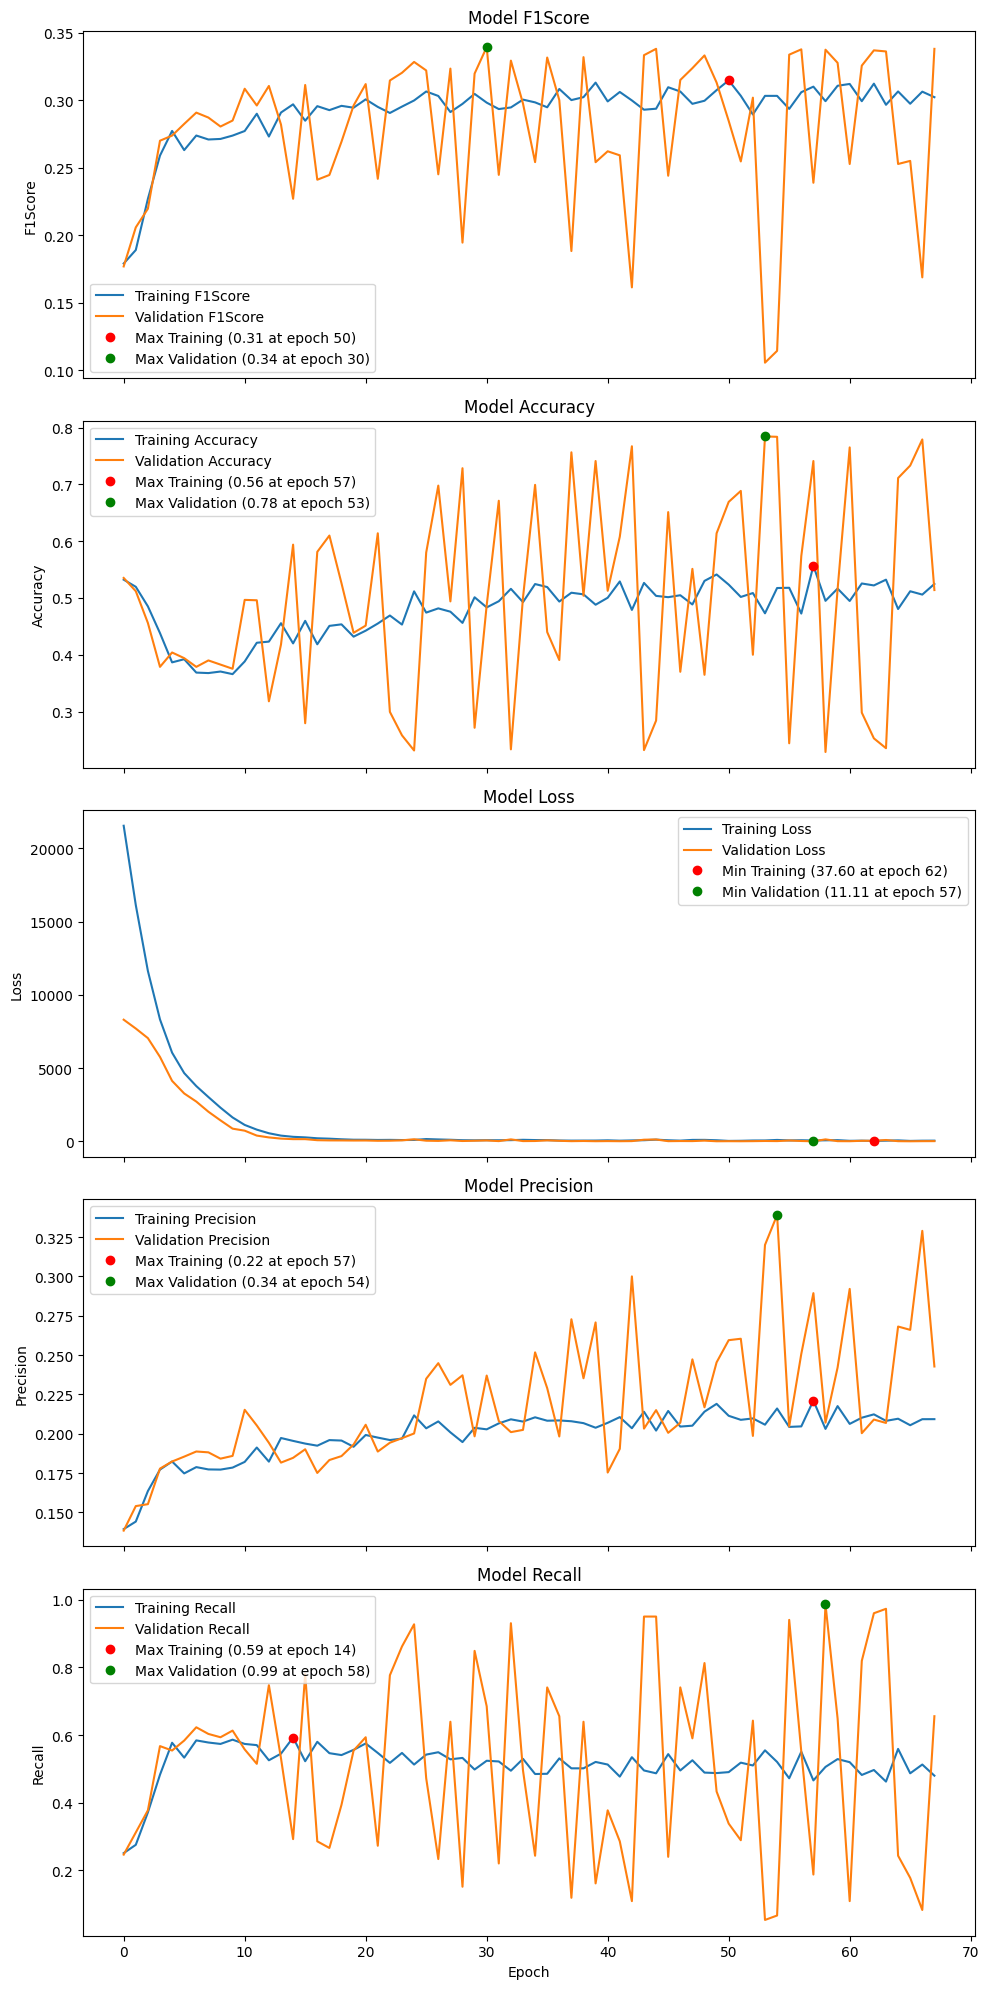

In [11]:
# Plot training and validation metrics on the same subplot for each metric
fig, axes = plt.subplots(len([key for key in history.history.keys() if not 'val' in key]), 1, figsize=(10, 4 * len([key for key in history.history.keys() if not 'val' in key])), sharex=True)

if len([key for key in history.history.keys() if not 'val' in key]) == 1:
    axes = [axes]

metric_names = [metric for metric in history.history.keys() if not 'val' in metric]

for i, metric_name in enumerate(metric_names):
    # Plot training metric
    axes[i].plot(history.history[metric_name], label=f'Training {metric_name.replace("_", " ").title()}')
    # Plot validation metric
    axes[i].plot(history.history[f'val_{metric_name}'], label=f'Validation {metric_name.replace("_", " ").title()}')

    axes[i].set_title(f'Model {metric_name.replace("_", " ").title()}')
    axes[i].set_ylabel(metric_name.replace("_", " ").title())
    axes[i].legend()

    # Add markers for the minimum/maximum on training and validation curves
    if 'loss' in metric_name or 'error' in metric_name: # Find minimum for loss and error metrics
        min_train_value = min(history.history[metric_name])
        min_train_epoch = history.history[metric_name].index(min_train_value)
        axes[i].plot(min_train_epoch, min_train_value, 'ro', label=f'Min Training ({min_train_value:.2f} at epoch {min_train_epoch})')

        min_val_value = min(history.history[f'val_{metric_name}'])
        min_val_epoch = history.history[f'val_{metric_name}'].index(min_val_value)
        axes[i].plot(min_val_epoch, min_val_value, 'go', label=f'Min Validation ({min_val_value:.2f} at epoch {min_val_epoch})')
        axes[i].legend()
    else: # Find maximum for other metrics (like R2)
        max_train_value = max(history.history[metric_name])
        max_train_epoch = history.history[metric_name].index(max_train_value)
        axes[i].plot(max_train_epoch, max_train_value, 'ro', label=f'Max Training ({max_train_value:.2f} at epoch {max_train_epoch})')

        max_val_value = max(history.history[f'val_{metric_name}'])
        max_val_epoch = history.history[f'val_{metric_name}'].index(max_val_value)
        axes[i].plot(max_val_epoch, max_val_value, 'go', label=f'Max Validation ({max_val_value:.2f} at epoch {max_val_epoch})')
        axes[i].legend()


axes[-1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [12]:
dnn_prediction = model.predict(X_test)
dnn_probabilities = sigmoid(dnn_prediction).numpy()
dnn_predicted_classes = (dnn_probabilities > 0.5).astype(int)
print(classification_report(y_test, dnn_predicted_classes))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.76      0.59      0.67      1194
           1       0.15      0.29      0.20       306

    accuracy                           0.53      1500
   macro avg       0.46      0.44      0.43      1500
weighted avg       0.64      0.53      0.57      1500



In [13]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    plt.close()

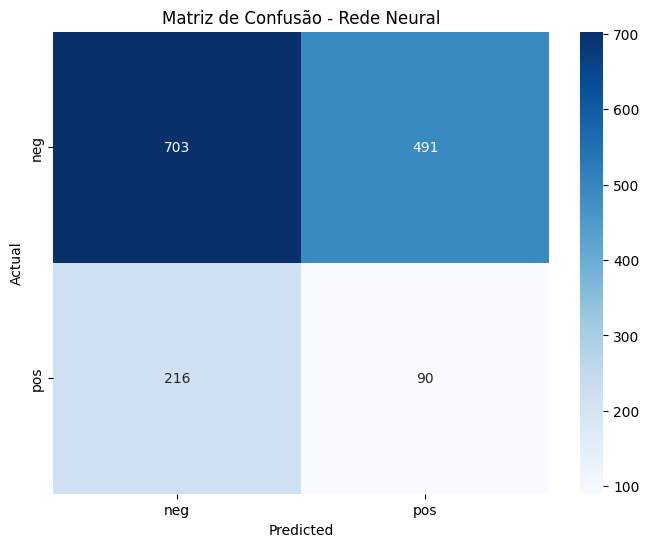

In [14]:
cm = confusion_matrix(y_test, dnn_predicted_classes)
plot_confusion_matrix(cm, 'Matriz de Confusão - Rede Neural')